In [1]:
import json
import time
import pyvisa
from RsInstrument import RsInstrument, BinFloatFormat
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlopen
from pathlib import Path
import os
import sys
from datetime import datetime
import matplotlib.colors as mcolors


In [2]:
rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

noise_source_bias = None
for instrument in instruments:
    if '33220A' in instrument:
        # Initialize instrument
        noise_source_bias = rm.open_resource(instrument) 
        break
print(noise_source_bias.query('*IDN?').strip())

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break

spa = None
for instrument in instruments:
    if '7405' in instrument:
        spa = rm.open_resource(instrument) 
        break

qubit_flux_bias = None
for instrument in instruments:
    if 'YOKOGAWA' in instrument:
        # Initialize instrument
        qubit_flux_bias = rm.open_resource(instrument) 
        break

WARM_SWITCHES_IP_ADDRESS = '169.254.12.12'
PROGRAMMABLE_ATTENUATOR_IP_ADDRESS = '169.254.11.11'

def send_url_command(ip_address, cmd_to_send):
    url = f"http://{ip_address}/:{cmd_to_send}"
    for attempt in range(3):
        try:
            with urlopen(url, timeout=3) as response:
                pte_return = response.read()
            if len(pte_return) > 100:
                print(f"Error, command not found: {url}")
                return "Invalid Command!"
            return pte_return.decode('utf-8').strip()
        except Exception as network_err:
            if attempt == 2:
                print(f"Hardware Network Warning: No response from {ip_address}. Error: {network_err}")
                return "No Response!"
            time.sleep(0.05)
            
def set_warm_switches_by_ip(ip_address, A, B, C, D):
    state_byte = 128 + int(A-1) + (2 * int(B-1)) + (4 * int(C-1)) + (8 * int(D-1))
    return send_url_command(ip_address, f"SETP={state_byte}")

def set_programmable_attenuator(attenuation):
    send_url_command(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS, f"SETATT={attenuation}")

def get_switch_state(ip_address):
    raw_reply = send_url_command(ip_address, "SWPORT?")
    if any(err in raw_reply for err in ["Error", "No Response"]):
        return {"status": "Disconnected or Error", "raw_reply": raw_reply}
    try:
        state_byte = int(raw_reply.strip())
        working_value = state_byte - 128
        return {
            "status": "Online",
            "raw_byte": state_byte,
            "A": working_value % 2 + 1,
            "B": (working_value // 2) % 2 + 1,
            "C": (working_value // 4) % 2 + 1,
            "D": (working_value // 8) % 16 + 1
        }
    except ValueError:
        return {"status": f"Malformed hardware response: {raw_reply}"}

def get_attenuator_state(ip_address):
    # The direct URL that successfully delivers the information
    url = f"http://{ip_address}/ATT?"
    
    try:
        with urlopen(url, timeout=2.0) as response:
            # Read bytes, decode to string, and remove whitespace/newlines
            attenuation_value = response.read().decode('utf-8').strip()
            return float(attenuation_value)
            
    except URLError as e:
        print(f"Connection failed: {e.reason}")
        return None
    except ValueError:
        print(f"Parsing Error: Could not convert response to number: {attenuation_value}")
        return None
vna.go_to_local()

Agilent Technologies,33220A,MY44053372,2.07-2.06-22-2


In [3]:
set_warm_switches_by_ip(WARM_SWITCHES_IP_ADDRESS, 1, 2, 1, 1) #vna to fridge to spectrum analyzer

'1'

scan complete5.0 dBm
189 seconds sweep time


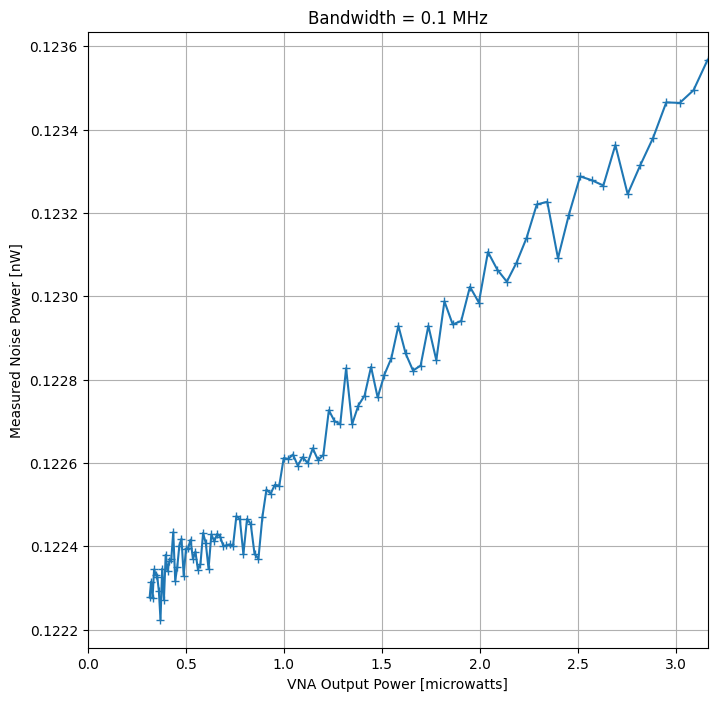

In [48]:
zero_bias_power_scan = {}

zero_bias_power_scan['cw_frequency'] = 5.58e9

zero_bias_power_scan['power_sweep_start'] = -35
zero_bias_power_scan['power_sweep_stop'] = -25
zero_bias_power_scan['power_sweep_number_of_points'] = 101

zero_bias_power_scan['power'] = np.linspace(zero_bias_power_scan['power_sweep_start'], zero_bias_power_scan['power_sweep_stop'], zero_bias_power_scan['power_sweep_number_of_points'])
zero_bias_power_scan['power'] = np.round(zero_bias_power_scan['power']*1000)/1000
zero_bias_power_scan['power'] = zero_bias_power_scan['power'].tolist()

zero_bias_power_scan['rbw'] = 1e5
zero_bias_power_scan['vbw'] = 100

try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

now = datetime.now().astimezone()
zero_bias_power_scan['timestamp'] = int(now.timestamp())
zero_bias_power_scan['date'] = now.strftime("%d-%m-%Y")
zero_bias_power_scan['time'] = now.strftime("%H:%M:%S")
zero_bias_power_scan['timezone'] = now.tzname()
zero_bias_power_scan['temperature'] = '0.011'
zero_bias_power_scan['start_time'] = int(now.timestamp())

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + zero_bias_power_scan['date'] + " Plots\n\n")

zero_bias_power_scan['programmable_attenuator'] = get_attenuator_state(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS)


spa.write(':SENS:BAND ' + str(zero_bias_power_scan['rbw']))
spa.write(':SENS:BAND:VID ' + str(zero_bias_power_scan['vbw']))
spa.write(":UNIT:POW W")

zero_bias_power_scan['ref_level'] = float(spa.query("DISP:WIND:TRAC:Y:RLEV?").strip())

zero_bias_power_scan['unit'] = spa.query(":UNIT:POW?").strip()

vna.write('SENSe1:SWEep:TYPE CW')
vna.write('SENSe1:FREQuency:CW ' + str(zero_bias_power_scan['cw_frequency']) + ' HZ')

spa.write('SENSe:FREQuency:SPAN 0 Hz')
spa.write('SENSe:FREQuency:CENTer ' + str(zero_bias_power_scan['cw_frequency']) + ' Hz')

zero_bias_power_scan['spa_number_of_points'] = int(spa.query(':SENS1:SWEep:POINts?'))

zero_bias_power_scan['noise'] = []
zero_bias_power_scan['noise_sigma'] = []

noise_source_bias.write("FUNC DC")
noise_source_bias.write("VOLT:OFFS 0.0")

for vna_power in zero_bias_power_scan['power']:
    vna.write('SOURce1:POWer ' +  str(vna_power))
    print(f"VNA Power: {vna_power} dBm", end="\r", flush=True)
    while True:
        try:
            spa.write("INIT:IMM")
            spa.query("*OPC?")
            trace = np.array(spa.query_ascii_values("TRAC? TRACE1"))
            if np.isnan(trace).any():
                raise ValueError
            zero_bias_power_scan['noise'].append(np.mean(trace))
            zero_bias_power_scan['noise_sigma'].append(np.std(trace))
            break
        except (pyvisa.errors.VisaIOError, ValueError):
            spa.clear()
            time.sleep(0.1)
    time.sleep(0.05)
vna.write('SOURce1:POWer -30')
print('scan complete')
now = datetime.now().astimezone()

zero_bias_power_scan['finish_time'] = int(now.timestamp())
zero_bias_power_scan['sweep_time'] = zero_bias_power_scan['finish_time'] - zero_bias_power_scan['start_time']
print(str(zero_bias_power_scan['sweep_time']) + " seconds sweep time")

sweep_file_name = f"{zero_bias_power_scan['timestamp']}-zero-bias-zero-span-power-sweep.json"
file_path = target_dir / sweep_file_name

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(zero_bias_power_scan, f, indent=4)

vna_power_out_microwatts = 1000*10**(np.array(zero_bias_power_scan['power'])/10)
noise_power_nanowatts = np.array(zero_bias_power_scan['noise'])/1e-9

plt.figure(figsize=(8,8))
plt.tight_layout()
plt.plot(vna_power_out_microwatts,noise_power_nanowatts,'+-')
plt.grid()
plt.xlim(0,vna_power_out_microwatts[-1])
plt.xlabel('VNA Output Power [microwatts]')
plt.ylabel('Measured Noise Power [nW]')
plt.title('Bandwidth = ' + str(zero_bias_power_scan['rbw']/1e6) + " MHz")

plot_file_name = f"{zero_bias_power_scan['timestamp']}-zero-bias-power-scan-plot.png"

with open(readme_path, "a") as file:
    file.write("![]("+ plot_file_name + ")\n")

with open(readme_path, "a") as file:
    file.write("\n### ["+ sweep_file_name + "]("+ sweep_file_name + ")\n")

plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
plt.show()


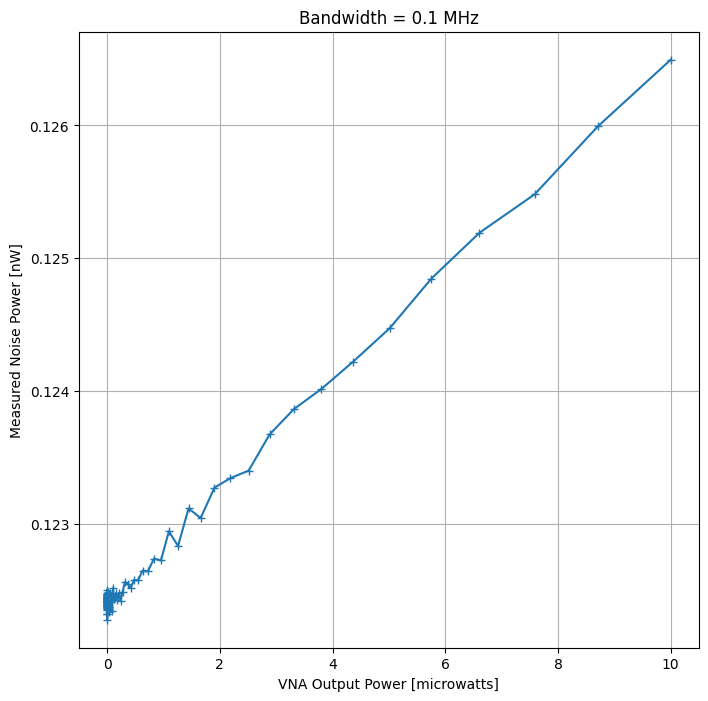

In [43]:
plt.figure(figsize=(8,8))
plt.tight_layout()
plt.plot(vna_power_out_microwatts,noise_power_nanowatts,'+-')
plt.grid()
#plt.xlim(0,0.1)
#plt.ylim(1.045,1.06)
plt.xlabel('VNA Output Power [microwatts]')
plt.ylabel('Measured Noise Power [nW]')
plt.title('Bandwidth = ' + str(zero_bias_power_scan['rbw']/1e6) + " MHz")
plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
plt.show()

In [37]:
zero_bias_power_scan['ref_level'] 


1e-07

In [38]:
spa.write("DISP:WIND:TRAC:Y:RLEV 1e-8")

28

In [40]:
float(spa.query("DISP:WIND:TRAC:Y:RLEV?").strip())


1e-08

In [46]:
spa.write(':SENS1:SWEep:POINts 1001')

26